# Regresión Lineal Simple: Teoría y Práctica

In [1]:
# Importamos las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Configuración básica de matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [10, 6]

## 1. El Modelo Matemático

```{admonition} Fundamentos
:class: important

La regresión lineal simple es un método estadístico que modeliza la relación entre una variable dependiente (y) y una variable independiente (x). Es "simple" porque solo hay una variable independiente y "lineal" porque el modelo es lineal en los parámetros.
```

### 1.1 Definición Formal

El modelo se expresa como:

```{math}
:label: modelo-base
y_i = \beta_0 + \beta_1 x_i + \epsilon_i, \quad i = 1, 2, ..., n
```

donde:
- $y_i$ es la variable dependiente (respuesta)
- $x_i$ es la variable independiente (predictora)
- $\beta_0$ es el intercepto
- $\beta_1$ es la pendiente
- $\epsilon_i$ es el término de error aleatorio

### 1.2 Supuestos del Modelo

Los supuestos fundamentales son:

```{list-table} Supuestos Estadísticos
:header-rows: 1
:name: tabla-supuestos

* - Supuesto
  - Expresión Matemática
  - Interpretación
* - 1
  - $E(\epsilon_i) = 0$
  - El modelo es correcto y $E(y_i) = \beta_0 + \beta_1 x_i$
* - 2
  - $var(\epsilon_i) = \sigma^2$
  - Homocedasticidad (varianza constante)
* - 3
  - $cov(\epsilon_i, \epsilon_j) = 0$
  - Errores no correlacionados
```

Veamos un ejemplo con datos simulados:

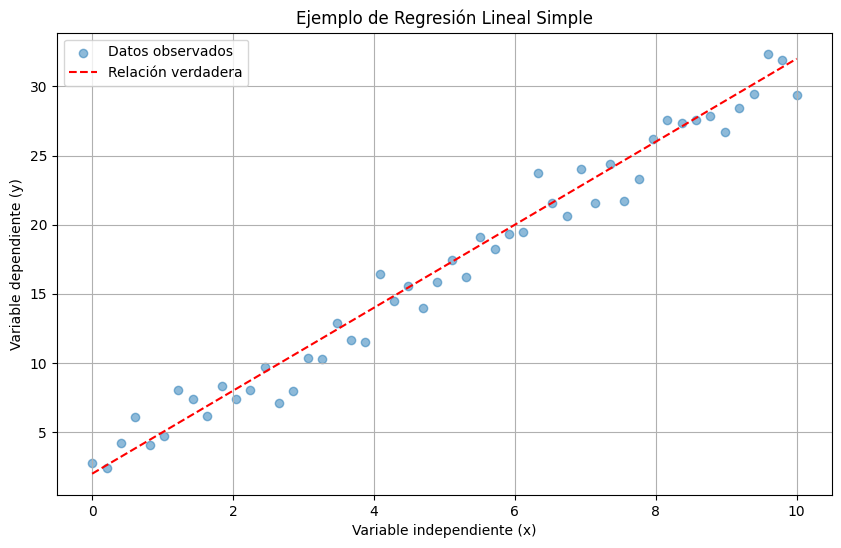

In [2]:
# Generamos datos que cumplen los supuestos
np.random.seed(42)
n = 50
x = np.linspace(0, 10, n)
epsilon = np.random.normal(0, 1.5, n)  # Errores normales independientes
beta0_true, beta1_true = 2, 3
y = beta0_true + beta1_true * x + epsilon

# Visualización
plt.scatter(x, y, alpha=0.5, label='Datos observados')
plt.plot(x, beta0_true + beta1_true * x, 'r--', label='Relación verdadera')
plt.xlabel('Variable independiente (x)')
plt.ylabel('Variable dependiente (y)')
plt.title('Ejemplo de Regresión Lineal Simple')
plt.legend()
plt.grid(True)
plt.show()

# 2. Estimación de Parámetros

## 2.1 Método de Mínimos Cuadrados

```{admonition} Principio de Mínimos Cuadrados
El método busca los valores de $\beta_0$ y $\beta_1$ que minimizan la suma de cuadrados de los residuos:

$\sum_{i=1}^n (y_i - \hat{y}i)^2 = \sum{i=1}^n (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2$
```



```{admonition} Objetivo
:class: important
Encontrar los valores de $\beta_0$ y $\beta_1$ que minimicen la suma de los cuadrados de las diferencias entre los valores observados y los valores predichos.
```

Definimos la función objetivo:

```{math}
:label: eq-objetivo
S(\beta_0, \beta_1) = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2
```

## 2.2 Condiciones de Primer Orden

Para minimizar $S(\beta_0, \beta_1)$, necesitamos que:

```{math}
:label: eq-condiciones
\begin{align*}
\frac{\partial S}{\partial \beta_0} &= 0 \\
\frac{\partial S}{\partial \beta_1} &= 0
\end{align*}
```

### 2.2.1 Primera Derivada Parcial

Desarrollamos $\frac{\partial S}{\partial \beta_0}$:

```{math}
:label: eq-derivada-beta0
\begin{align*}
\frac{\partial S}{\partial \beta_0} &= \frac{\partial}{\partial \beta_0} \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2 \\
&= \sum_{i=1}^n \frac{\partial}{\partial \beta_0} (y_i - \beta_0 - \beta_1 x_i)^2 \\
&= \sum_{i=1}^n 2(y_i - \beta_0 - \beta_1 x_i)(-1) \\
&= -2\sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i) = 0
\end{align*}
```

### 2.2.2 Segunda Derivada Parcial

Desarrollamos $\frac{\partial S}{\partial \beta_1}$:

```{math}
:label: eq-derivada-beta1
\begin{align*}
\frac{\partial S}{\partial \beta_1} &= \frac{\partial}{\partial \beta_1} \sum_{i=1}^n (y_i - \beta_0 - \beta_1 x_i)^2 \\
&= \sum_{i=1}^n \frac{\partial}{\partial \beta_1} (y_i - \beta_0 - \beta_1 x_i)^2 \\
&= \sum_{i=1}^n 2(y_i - \beta_0 - \beta_1 x_i)(-x_i) \\
&= -2\sum_{i=1}^n x_i(y_i - \beta_0 - \beta_1 x_i) = 0
\end{align*}
```

## 2.3 Sistema de Ecuaciones Normales

De {eq}`eq-derivada-beta0`:
```{math}
:label: eq-normal1
\sum_{i=1}^n y_i - n\beta_0 - \beta_1 \sum_{i=1}^n x_i = 0
```

De {eq}`eq-derivada-beta1`:
```{math}
:label: eq-normal2
\sum_{i=1}^n x_iy_i - \beta_0 \sum_{i=1}^n x_i - \beta_1 \sum_{i=1}^n x_i^2 = 0
```

## 2.4 Solución del Sistema

### 2.4.1 Obtención de $\beta_0$

De {eq}`eq-normal1`:
```{math}
:label: eq-beta0-1
\beta_0 = \frac{\sum_{i=1}^n y_i}{n} - \beta_1 \frac{\sum_{i=1}^n x_i}{n} = \bar{y} - \beta_1 \bar{x}
```

### 2.4.2 Obtención de $\beta_1$

Sustituyendo {eq}`eq-beta0-1` en {eq}`eq-normal2`:

```{math}
:label: eq-beta1-desarrollo
\begin{align*}
\sum_{i=1}^n x_iy_i - (\bar{y} - \beta_1 \bar{x})\sum_{i=1}^n x_i - \beta_1 \sum_{i=1}^n x_i^2 &= 0 \\
\sum_{i=1}^n x_iy_i - \bar{y}\sum_{i=1}^n x_i + \beta_1 \bar{x}\sum_{i=1}^n x_i - \beta_1 \sum_{i=1}^n x_i^2 &= 0
\end{align*}
```

Reordenando términos:

```{math}
:label: eq-beta1-final
\beta_1 = \frac{\sum_{i=1}^n x_iy_i - \bar{y}\sum_{i=1}^n x_i}{\sum_{i=1}^n x_i^2 - \bar{x}\sum_{i=1}^n x_i}
```

### 2.4.3 Forma Alternativa de $\beta_1$

Podemos reescribir $\beta_1$ en términos de desviaciones respecto a la media:

```{math}
:label: eq-beta1-alt
\begin{align*}
\beta_1 &= \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} \\
&= \frac{Cov(x,y)}{Var(x)}
\end{align*}
```

## 2.5 Verificación de Mínimo

Para confirmar que hemos encontrado un mínimo y no un máximo, verificamos las segundas derivadas:

```{math}
:label: eq-segundas-derivadas
\begin{align*}
\frac{\partial^2 S}{\partial \beta_0^2} &= 2n > 0 \\
\frac{\partial^2 S}{\partial \beta_1^2} &= 2\sum_{i=1}^n x_i^2 > 0 \\
\frac{\partial^2 S}{\partial \beta_0\partial \beta_1} &= 2\sum_{i=1}^n x_i
\end{align*}
```

La matriz Hessiana es:
```{math}
:label: eq-hessiana
H = 2\begin{bmatrix} 
n & \sum x_i \\
\sum x_i & \sum x_i^2
\end{bmatrix}
```

Es definida positiva, confirmando que hemos encontrado un mínimo global.

## 2.6 Propiedades Algebraicas

Las soluciones tienen las siguientes propiedades:

1. $\sum_{i=1}^n (y_i - \hat{y}_i) = 0$
2. $\sum_{i=1}^n x_i(y_i - \hat{y}_i) = 0$
3. $\sum_{i=1}^n \hat{y}_i = \sum_{i=1}^n y_i$
4. $\hat{y} = \bar{y}$

```{note}
Estas propiedades son consecuencia directa de las condiciones de primer orden y son fundamentales para la inferencia estadística en regresión lineal.
```

Implementemos estas fórmulas:

Estimadores de mínimos cuadrados:
β₀: 2.0967 (verdadero: 2)
β₁: 2.9130 (verdadero: 3)


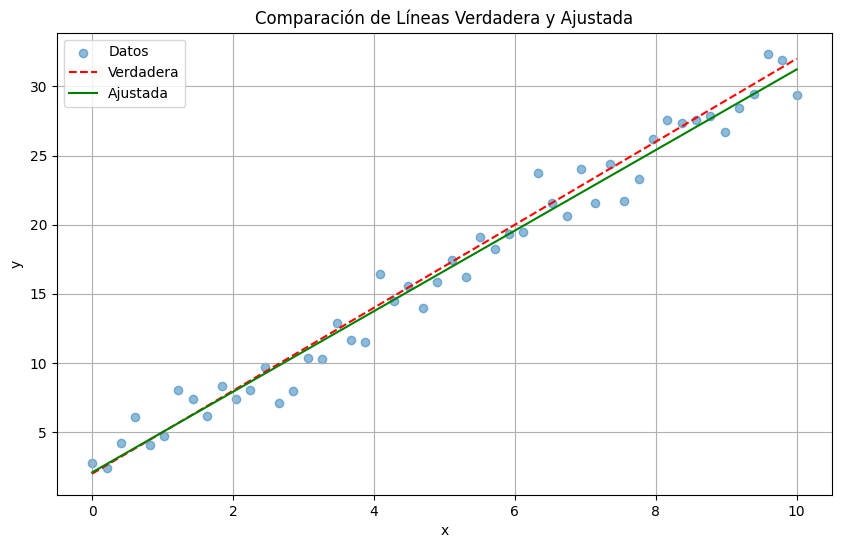

In [3]:
def calcular_estimadores_mc(x, y):
    """Calcula los estimadores de mínimos cuadrados"""
    x_mean, y_mean = np.mean(x), np.mean(y)
    beta1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
    beta0 = y_mean - beta1 * x_mean
    return beta0, beta1

beta0_est, beta1_est = calcular_estimadores_mc(x, y)
print(f'Estimadores de mínimos cuadrados:')
print(f'β₀: {beta0_est:.4f} (verdadero: {beta0_true})')
print(f'β₁: {beta1_est:.4f} (verdadero: {beta1_true})')

# Visualización del ajuste
plt.scatter(x, y, alpha=0.5, label='Datos')
plt.plot(x, beta0_true + beta1_true * x, 'r--', label='Verdadera')
plt.plot(x, beta0_est + beta1_est * x, 'g-', label='Ajustada')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparación de Líneas Verdadera y Ajustada')
plt.legend()
plt.grid(True)
plt.show()

```{admonition} Observación
:class: tip
Los estimadores de mínimos cuadrados son insesgados y eficientes bajo los supuestos del modelo.
```

## 3. Propiedades de los Estimadores

```{admonition} Propiedades Teóricas
:class: important
Bajo los supuestos del modelo, los estimadores de mínimos cuadrados son:
1. Insesgados: $E(\hat{\beta}_0) = \beta_0$ y $E(\hat{\beta}_1) = \beta_1$
2. De mínima varianza entre todos los estimadores lineales insesgados
```

Las varianzas de los estimadores son:

```{math}
:label: varianzas
\begin{align*}
var(\hat{\beta}_1) &= \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2} \\
var(\hat{\beta}_0) &= \sigma^2(\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2})
\end{align*}
```
## 3.1 Insesgamiento

### 3.1.1 Insesgamiento de $\hat{\beta}_1$

```{admonition} Teorema
:class: important
El estimador $\hat{\beta}_1$ es insesgado, es decir, $E(\hat{\beta}_1) = \beta_1$
```

Demostración:

```{math}
:label: eq-unbiased-beta1
\begin{align*}
E(\hat{\beta}_1) &= E\left[\frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}\right] \\
&= \frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2}E\left[\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})\right]
\end{align*}
```

Dado que $y_i = \beta_0 + \beta_1x_i + \epsilon_i$:

```{math}
:label: eq-unbiased-beta1-cont
\begin{align*}
E(y_i) &= \beta_0 + \beta_1x_i \\
E(\bar{y}) &= \beta_0 + \beta_1\bar{x}
\end{align*}
```

Sustituyendo:

```{math}
:label: eq-unbiased-beta1-final
\begin{align*}
E(\hat{\beta}_1) &= \frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2}\sum_{i=1}^n (x_i - \bar{x})(\beta_0 + \beta_1x_i - \beta_0 - \beta_1\bar{x}) \\
&= \frac{1}{\sum_{i=1}^n (x_i - \bar{x})^2}\sum_{i=1}^n (x_i - \bar{x})\beta_1(x_i - \bar{x}) \\
&= \beta_1\frac{\sum_{i=1}^n (x_i - \bar{x})^2}{\sum_{i=1}^n (x_i - \bar{x})^2} = \beta_1
\end{align*}
```

### 3.1.2 Insesgamiento de $\hat{\beta}_0$

```{admonition} Teorema
:class: important
El estimador $\hat{\beta}_0$ es insesgado, es decir, $E(\hat{\beta}_0) = \beta_0$
```

Demostración:

```{math}
:label: eq-unbiased-beta0
\begin{align*}
E(\hat{\beta}_0) &= E(\bar{y} - \hat{\beta}_1\bar{x}) \\
&= E(\bar{y}) - \bar{x}E(\hat{\beta}_1) \\
&= (\beta_0 + \beta_1\bar{x}) - \bar{x}\beta_1 \\
&= \beta_0
\end{align*}
```

## 3.2 Varianzas de los Estimadores

### 3.2.1 Varianza de $\hat{\beta}_1$

```{math}
:label: eq-var-beta1
\begin{align*}
var(\hat{\beta}_1) &= var\left[\frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2}\right] \\
&= \frac{1}{[\sum_{i=1}^n (x_i - \bar{x})^2]^2}var\left[\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})\right]
\end{align*}
```

Dado que $var(y_i) = \sigma^2$ y los errores son independientes:

```{math}
:label: eq-var-beta1-final
var(\hat{\beta}_1) = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2}
```

### 3.2.2 Varianza de $\hat{\beta}_0$

```{math}
:label: eq-var-beta0
\begin{align*}
var(\hat{\beta}_0) &= var(\bar{y} - \hat{\beta}_1\bar{x}) \\
&= var(\bar{y}) + \bar{x}^2var(\hat{\beta}_1) - 2\bar{x}cov(\bar{y},\hat{\beta}_1)
\end{align*}
```

Después de desarrollar los términos:

```{math}
:label: eq-var-beta0-final
var(\hat{\beta}_0) = \sigma^2(\frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2})
```

## 3.3 Teorema de Gauss-Markov

```{admonition} Teorema de Gauss-Markov
:class: important
Entre todos los estimadores lineales e insesgados de $\beta_0$ y $\beta_1$, los estimadores de mínimos cuadrados tienen varianza mínima.
```

### 3.3.1 Demostración del Teorema

Sea $\tilde{\beta}_1$ otro estimador lineal insesgado de $\beta_1$:

```{math}
:label: eq-gauss-markov
\begin{align*}
\tilde{\beta}_1 &= \sum_{i=1}^n a_iy_i \\
E(\tilde{\beta}_1) &= \beta_1 \implies \sum_{i=1}^n a_ix_i = 1 \text{ y } \sum_{i=1}^n a_i = 0
\end{align*}
```

Entonces:

```{math}
:label: eq-gauss-markov-var
var(\tilde{\beta}_1) = \sigma^2\sum_{i=1}^n a_i^2 \geq \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2} = var(\hat{\beta}_1)
```

## 3.4 Propiedades de los Residuos

Los residuos $\hat{\epsilon}_i = y_i - \hat{y}_i$ tienen las siguientes propiedades:

1. $\sum_{i=1}^n \hat{\epsilon}_i = 0$
2. $\sum_{i=1}^n x_i\hat{\epsilon}_i = 0$
3. $\sum_{i=1}^n \hat{y}_i\hat{\epsilon}_i = 0$
4. $Cov(\hat{y}_i, \hat{\epsilon}_i) = 0$

```{note}
Estas propiedades son fundamentales para la inferencia estadística y la validación del modelo.
```

## 3.5 Consecuencias Prácticas

1. **Eficiencia**: Los estimadores MCO son los mejores estimadores lineales insesgados (BLUE).

2. **Precisión**:
   - La precisión de $\hat{\beta}_1$ aumenta con:
     * Mayor variabilidad en x ($\sum_{i=1}^n (x_i - \bar{x})^2$ grande)
     * Menor varianza del error ($\sigma^2$ pequeño)
     * Mayor tamaño muestral (n)

3. **Intervalo de Confianza**:
   - Los intervalos de confianza serán más estrechos cuando:
     * Las varianzas sean menores
     * El tamaño muestral sea mayor

In [4]:
# Simulación para verificar insesgamiento
n_sims = 1000
beta0_sims = np.zeros(n_sims)
beta1_sims = np.zeros(n_sims)

for i in range(n_sims):
    epsilon = np.random.normal(0, 1.5, n)
    y_sim = beta0_true + beta1_true * x + epsilon
    beta0_sims[i], beta1_sims[i] = calcular_estimadores_mc(x, y_sim)

print("Resultados de simulación:")
print(f'E(β₀): {np.mean(beta0_sims):.4f} (verdadero: {beta0_true})')
print(f'E(β₁): {np.mean(beta1_sims):.4f} (verdadero: {beta1_true})')

Resultados de simulación:
E(β₀): 2.0035 (verdadero: 2)
E(β₁): 2.9993 (verdadero: 3)


```{admonition} Observación
:class: tip
Los resultados de la simulación confirman que los estimadores de mínimos cuadrados son insesgados.
```

In [5]:
# Simulación para verificar varianzas
sigma2 = 1.5**2
var_beta0 = sigma2 * (1/n + np.mean(x)**2 / np.sum((x - np.mean(x))**2))
var_beta1 = sigma2 / np.sum((x - np.mean(x))**2)

print("Varianzas de los estimadores:")
print(f'var(β₀): {var_beta0:.4f}')

Varianzas de los estimadores:
var(β₀): 0.1747


## 4. Inferencia Estadística en Regresión Lineal

### 4.1 Estimación de la Varianza (σ²)

La varianza del error (σ²) es un parámetro crucial que mide la dispersión de los datos alrededor de la línea de regresión. Su estimación es fundamental para:
- Calcular errores estándar de los coeficientes
- Construir intervalos de confianza
- Realizar pruebas de hipótesis

```python
import numpy as np
from scipy import stats

def estimate_variance(y, y_pred, n_params=2):
    """
    Estima la varianza del error en regresión lineal.
    
    Parámetros:
    -----------
    y : array-like
        Valores observados
    y_pred : array-like
        Valores predichos
    n_params : int
        Número de parámetros en el modelo (default=2 para regresión simple)
        
    Retorna:
    --------
    float
        Estimación de σ²
    """
    n = len(y)
    residuals = y - y_pred
    sigma2 = np.sum(residuals**2) / (n - n_params)
    return sigma2

# Ejemplo de uso
y_pred = beta0_est + beta1_est * x
sigma2_est = estimate_variance(y, y_pred)
print(f'σ² estimado: {sigma2_est:.4f}')
```

```python
# Visualización de residuos
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, y - y_pred, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Valores predichos')
plt.ylabel('Residuos')
plt.title('Gráfico de Residuos vs Valores Predichos')
plt.grid(True)
plt.show()
```

### 4.2 Pruebas de Hipótesis

Las pruebas de hipótesis nos permiten evaluar la significancia estadística de los coeficientes.

```python
def test_beta1(beta1, x, sigma2, alpha=0.05):
    """
    Realiza prueba de hipótesis para β₁
    
    H₀: β₁ = 0 
    H₁: β₁ ≠ 0
    
    Parámetros:
    -----------
    beta1 : float
        Estimación de β₁
    x : array-like
        Variable independiente
    sigma2 : float
        Varianza estimada
    alpha : float
        Nivel de significancia
        
    Retorna:
    --------
    dict
        Resultados del test
    """
    n = len(x)
    # Error estándar
    se = np.sqrt(sigma2 / np.sum((x - np.mean(x))**2))
    
    # Estadístico t
    t_stat = beta1 / se
    
    # Grados de libertad
    df = n - 2
    
    # Valor p
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=df))
    
    # Intervalo de confianza
    t_crit = stats.t.ppf(1-alpha/2, df=df)
    ci = (beta1 - t_crit * se, beta1 + t_crit * se)
    
    return {
        't_statistic': t_stat,
        'p_value': p_value,
        'confidence_interval': ci
    }

# Ejemplo de uso
results = test_beta1(beta1_est, x, sigma2_est)
print(f"Estadístico t: {results['t_statistic']:.4f}")
print(f"Valor p: {results['p_value']:.4e}")
print(f"IC 95%: [{results['confidence_interval'][0]:.4f}, {results['confidence_interval'][1]:.4f}]")
```

### 4.3 Intervalos de Predicción

Los intervalos de predicción proporcionan un rango para futuras observaciones.

```python
def prediction_interval(x_new, x, beta0, beta1, sigma2, alpha=0.05):
    """
    Calcula intervalo de predicción para nuevas observaciones
    
    Parámetros:
    -----------
    x_new : float o array-like
        Nuevos valores de x para predicción
    x : array-like
        Valores originales de x
    beta0, beta1 : float
        Coeficientes estimados
    sigma2 : float
        Varianza estimada
    alpha : float
        Nivel de significancia
    
    Retorna:
    --------
    tuple
        (predicción, límite inferior, límite superior)
    """
    n = len(x)
    x_mean = np.mean(x)
    
    # Predicción puntual
    y_pred = beta0 + beta1 * x_new
    
    # Error estándar de predicción
    se_pred = np.sqrt(sigma2 * (1 + 1/n + 
                     (x_new - x_mean)**2 / np.sum((x - x_mean)**2)))
    
    # Valor crítico
    t_crit = stats.t.ppf(1-alpha/2, df=n-2)
    
    # Intervalos
    pi_lower = y_pred - t_crit * se_pred
    pi_upper = y_pred + t_crit * se_pred
    
    return y_pred, pi_lower, pi_upper

# Ejemplo de uso
x_new = np.linspace(min(x), max(x), 100)
predictions = prediction_interval(x_new, x, beta0_est, beta1_est, sigma2_est)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Datos observados')
plt.plot(x_new, predictions[0], 'r-', label='Regresión')
plt.fill_between(x_new, predictions[1], predictions[2], 
                 alpha=0.2, label='Intervalo de predicción 95%')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Regresión con Intervalos de Predicción')
plt.legend()
plt.grid(True)
plt.show()
```



# 5. Bondad de Ajuste en Regresión Lineal

## 5.1 Coeficiente de Determinación (R²)

El R² es una medida fundamental que indica la proporción de la variabilidad en los datos que es explicada por el modelo de regresión.

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def calculate_r2(y, y_pred):
    """
    Calcula el coeficiente de determinación R².
    
    Parámetros:
    -----------
    y : array-like
        Valores observados
    y_pred : array-like
        Valores predichos
        
    Retorna:
    --------
    float
        Valor de R²
    dict
        Componentes del cálculo (SST, SSR, SSE)
    """
    # Suma total de cuadrados (SST)
    ss_tot = np.sum((y - np.mean(y))**2)
    
    # Suma de cuadrados de la regresión (SSR)
    ss_reg = np.sum((y_pred - np.mean(y))**2)
    
    # Suma de cuadrados del error (SSE)
    ss_res = np.sum((y - y_pred)**2)
    
    # Cálculo de R²
    r2 = 1 - (ss_res / ss_tot)
    # Alternativamente: r2 = ss_reg / ss_tot
    
    return r2, {
        'SST': ss_tot,
        'SSR': ss_reg,
        'SSE': ss_res
    }

def plot_goodness_of_fit(y, y_pred, r2):
    """
    Genera visualizaciones para evaluar la bondad de ajuste.
    
    Parámetros:
    -----------
    y : array-like
        Valores observados
    y_pred : array-like
        Valores predichos
    r2 : float
        Coeficiente de determinación
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico de valores observados vs predichos
    ax1.scatter(y, y_pred, alpha=0.5)
    ax1.plot([min(y), max(y)], [min(y), max(y)], 'r--', 
             label='Línea de referencia')
    ax1.set_xlabel('Valores Observados')
    ax1.set_ylabel('Valores Predichos')
    ax1.set_title(f'Observado vs Predicho (R² = {r2:.4f})')
    ax1.grid(True)
    ax1.legend()
    
    # Gráfico Q-Q de residuos
    residuals = y - y_pred
    stats.probplot(residuals, dist="norm", plot=ax2)
    ax2.set_title('Gráfico Q-Q de Residuos')
    
    plt.tight_layout()
    plt.show()

# Ejemplo de uso
r2, components = calculate_r2(y, y_pred)
plot_goodness_of_fit(y, y_pred, r2)

print("\nComponentes de la variabilidad:")
print(f"Variabilidad total (SST): {components['SST']:.4f}")
print(f"Variabilidad explicada (SSR): {components['SSR']:.4f}")
print(f"Variabilidad residual (SSE): {components['SSE']:.4f}")
print(f"\nR² = {r2:.4f}")
```

## 5.2 R² Ajustado

El R² ajustado penaliza la adición de variables predictoras que no mejoran significativamente el modelo.

```python
def adjusted_r2(r2, n, p):
    """
    Calcula el R² ajustado.
    
    Parámetros:
    -----------
    r2 : float
        R² original
    n : int
        Número de observaciones
    p : int
        Número de predictores (sin incluir intercepto)
        
    Retorna:
    --------
    float
        R² ajustado
    """
    adj_r2 = 1 - (1 - r2) * ((n - 1) / (n - p - 1))
    return adj_r2

# Ejemplo de uso
n = len(y)  # número de observaciones
p = 1       # número de predictores (sin intercepto)
adj_r2 = adjusted_r2(r2, n, p)
print(f"R² ajustado: {adj_r2:.4f}")
```

## 5.3 Medidas Adicionales de Ajuste

```python
def additional_metrics(y, y_pred):
    """
    Calcula métricas adicionales de bondad de ajuste.
    
    Parámetros:
    -----------
    y : array-like
        Valores observados
    y_pred : array-like
        Valores predichos
        
    Retorna:
    --------
    dict
        Diccionario con diferentes métricas
    """
    n = len(y)
    residuals = y - y_pred
    
    # Error cuadrático medio (MSE)
    mse = np.mean(residuals**2)
    
    # Raíz del error cuadrático medio (RMSE)
    rmse = np.sqrt(mse)
    
    # Error absoluto medio (MAE)
    mae = np.mean(np.abs(residuals))
    
    # Error porcentual absoluto medio (MAPE)
    mape = np.mean(np.abs(residuals / y)) * 100
    
    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE': mape
    }

# Ejemplo de uso
metrics = additional_metrics(y, y_pred)
for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")
```